# Molecfit Parallel Wrapper User Guide

Small guide to use `Molecfit_parallel_wrapper.py`.

Workflow:
1. Choose the instrument section below (HARPS, ESPRESSO, NIRPS, CARMENES VIS/NIR).
2. Build the CSV used by the wrapper (`path,berv`).
3. Set `PATH_TO_LIST` and `CONFIGURED_CHANNEL_TYPE` in `Molecfit_parallel_wrapper.py`.
4. Run the wrapper from terminal.
5. Plot Molecfit outputs.

In VS Code, use the notebook outline as tabs (one section per instrument).

## Wrapper Data and Folder Structure

Before running cells, keep this role split in the repository:

- `Molecfit_parallel_wrapper.py`: executable wrapper that runs Molecfit.
- `wrapper_user_guide.ipynb`: interface notebook to prepare inputs and visualize results.
- `Parameter_Files/`: static template and telluric include/exclude windows.
- `Automated_Program/`: runtime CSV inputs (`path,berv`) and temporary files produced during execution.
- `s1d_carmenes_nir/` and `s1d_carmenes_vis/`: prepared S1D FITS files used as wrapper inputs.
- `Output/`: per-spectrum Molecfit run folders generated automatically.
- `Final_Results_Molecfit/`: consolidated TAC outputs and run summary CSV.
- `backup/`: archived legacy material not required for the clean workflow.

Minimal run path:

1. Build or update CSV inputs in `Automated_Program/` from instrument sections below.
2. Set `PATH_TO_LIST` and `CONFIGURED_CHANNEL_TYPE` in `Molecfit_parallel_wrapper.py`.
3. Run the wrapper.
4. Inspect `Output/` and `Final_Results_Molecfit/`.


In [1]:
import os
import glob
import copy
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy import constants as const
from scipy.interpolate import interp1d

# PyAstronomy is used only for HARPS air->vacuum conversion.
# Install with:  pip install PyAstronomy
try:
    from PyAstronomy import pyasl as _pyasl
    _PYASL_OK = True
except ImportError:
    _PYASL_OK = False
    print("WARNING: PyAstronomy not found. HARPS air->vacuum conversion will be skipped.")
    print("         Install with:  pip install PyAstronomy")

%load_ext autoreload
%autoreload 2
%matplotlib widget


## Shared Helpers

In [2]:
def write_wrapper_csv(paths, berv_values, csv_path):
    """Create wrapper CSV with required columns: path, berv."""
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    rows = []
    for p, b in zip(paths, berv_values):
        rows.append({"path": str(p), "berv": float(b) if np.isfinite(float(b)) else np.nan})
    df = pd.DataFrame(rows, columns=["path", "berv"])
    df.to_csv(csv_path, index=False)
    return df


def build_csv_from_s1d_dir(data_dir, pattern, berv_key, csv_path, berv_factor=1e3,
                            sort_key=None):
    """
    Scan a DRS output directory for S1D files, read the BERV from each header,
    and write the wrapper CSV (path, berv).

    Parameters
    ----------
    data_dir    : str   — directory containing the S1D FITS files.
    pattern     : str   — glob pattern to select S1D files, e.g. '*s1d_A.fits'.
    berv_key    : str   — FITS header key for the BERV value.
    csv_path    : str   — output CSV path.
    berv_factor : float — multiply the header value by this to get m/s
                          (DRS usually stores in km/s → default 1e3).
    sort_key    : str   — optional header key to sort by (e.g. 'MJD-OBS').
                          If None, files are sorted alphabetically.

    Returns
    -------
    pd.DataFrame with columns ['path', 'berv'].
    """
    files = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not files:
        raise FileNotFoundError(f"No files matching '{pattern}' found in {data_dir}")

    if sort_key is not None:
        files = sorted(files, key=lambda f: fits.getheader(f).get(sort_key, 0))

    rows = []
    for fpath in files:
        hdr  = fits.getheader(fpath)
        berv = hdr.get(berv_key, np.nan)
        if np.isfinite(float(berv)):
            berv = float(berv) * berv_factor
        rows.append({"path": fpath, "berv": berv})

    df = pd.DataFrame(rows, columns=["path", "berv"])
    os.makedirs(os.path.dirname(os.path.abspath(csv_path)), exist_ok=True)
    df.to_csv(csv_path, index=False)
    print(f"Wrote {len(df)} entries → {csv_path}")
    return df


def _merge_overlaps_sorted(wave, flux, err, tol):
    """Fast overlap merge using vectorized inverse-variance weighting."""
    if wave.size == 0:
        return wave, flux, err

    labels = np.zeros(wave.size, dtype=np.intp)
    labels[1:] = np.cumsum(np.diff(wave) > tol)
    n_groups = int(labels[-1]) + 1

    good = np.isfinite(wave) & np.isfinite(flux) & np.isfinite(err) & (err > 0)
    wgt = np.where(good, 1.0 / (err * err), 0.0)

    sw = np.zeros(n_groups)
    sww = np.zeros(n_groups)
    swf = np.zeros(n_groups)
    np.add.at(sw, labels, wgt)
    np.add.at(sww, labels, wgt * wave)
    np.add.at(swf, labels, wgt * flux)

    valid = sw > 0
    return sww[valid] / sw[valid], swf[valid] / sw[valid], np.sqrt(1.0 / sw[valid])


def prepare_s1d(dd, output_dir, csv_path, channel, berv_in_kms=False,
                err_mode="snr", default_snr=100.0, merge_overlaps=True,
                overlap_tol_factor=0.25, min_points=32):
    """
    Build one S1D FITS per observation from order spectra and create wrapper CSV.
    Used for instruments whose DRS does NOT produce S1D files (e.g. CARMENES).
    Output FITS format is compatible with the wrapper (BinTable with WAVE/FLUX/ERR).
    """
    os.makedirs(output_dir, exist_ok=True)
    rows = []

    for i_obs in range(int(dd.data.shape[0])):
        fname = dd.files[i_obs]
        with fits.open(dd.path + fname) as hdul:
            primary_header = hdul[0].header.copy()

        wave_1d = np.asarray(dd.wave[i_obs], dtype=float).ravel()
        flux_1d = np.asarray(dd.data[i_obs], dtype=float).ravel()

        good = np.isfinite(wave_1d) & np.isfinite(flux_1d)
        wave_1d = wave_1d[good]
        flux_1d = flux_1d[good]

        s = np.argsort(wave_1d)
        wave_1d = wave_1d[s]
        flux_1d = flux_1d[s]

        if wave_1d.size < min_points:
            continue

        snr = (float(dd.SNR[i_obs])
               if (hasattr(dd, 'SNR') and dd.SNR is not None
                   and np.isfinite(float(dd.SNR[i_obs]))
                   and float(dd.SNR[i_obs]) > 0)
               else default_snr)

        if err_mode == "snr":
            err_1d = np.full_like(flux_1d, 1.0 / max(snr, 1.0))
        else:
            err_1d = np.ones_like(flux_1d)

        if merge_overlaps:
            d = np.diff(wave_1d)
            d = d[np.isfinite(d) & (d > 0)]
            if d.size > 0:
                tol = overlap_tol_factor * np.nanmedian(d)
                wave_1d, flux_1d, err_1d = _merge_overlaps_sorted(wave_1d, flux_1d, err_1d, tol)

        if wave_1d.size < min_points:
            continue

        table = Table([[wave_1d], [flux_1d], [err_1d]], names=["WAVE", "FLUX", "ERR"])
        obs_key = os.path.splitext(os.path.basename(fname))[0]
        out_path = os.path.join(output_dir, f"{obs_key}_S1D_{str(channel).upper()}.fits")

        fits.HDUList([
            fits.PrimaryHDU(header=primary_header),
            fits.BinTableHDU(table)
        ]).writeto(out_path, overwrite=True, output_verify="silentfix")

        berv = float(dd.BERV[i_obs]) if hasattr(dd, "BERV") else np.nan
        if berv_in_kms and np.isfinite(berv):
            berv *= 1000.0

        rows.append({"path": out_path, "berv": berv})

    df = pd.DataFrame(rows, columns=["path", "berv"])
    df.to_csv(csv_path, index=False)
    return df


In [3]:
def read_fit_ascii(path):
    names = ["chip", "lambda", "flux", "weight", "mrange", "mlambda", "mscal", "mflux", "mweight", "dev", "mtrans"]
    arr = np.genfromtxt(path, comments='!', names=names, usecols=tuple(range(1, 12)), skip_header=1)
    return (
        np.asarray(arr['lambda'], dtype=float),
        np.asarray(arr['flux'], dtype=float),
        np.asarray(arr['mlambda'], dtype=float),
        np.asarray(arr['mflux'], dtype=float),
    )


def read_tac_ascii(path):
    names = ["chip", "lambda", "flux", "weight", "mlambda", "mtrans", "mweight", "cflux", "qual"]
    arr = np.genfromtxt(path, comments='!', names=names, usecols=tuple(range(1, 10)), skip_header=1)
    return (
        np.asarray(arr['lambda'], dtype=float),
        np.asarray(arr['flux'], dtype=float),
        np.asarray(arr['mlambda'], dtype=float),
        np.asarray(arr['mtrans'], dtype=float),
        np.asarray(arr['cflux'], dtype=float),
    )


def plot_molecfit_result(run_dir, spectrum_index=0):
    fit_path = os.path.join(run_dir, f"Spectrum_{spectrum_index}_fit.asc")
    tac_path = os.path.join(run_dir, f"Spectrum_{spectrum_index}_tac.asc")

    if (not os.path.exists(fit_path)) or (not os.path.exists(tac_path)):
        raise FileNotFoundError("Missing fit/tac ASCII files in run_dir")

    w_fit, f_fit, w_model_fit, model_fit = read_fit_ascii(fit_path)
    w_tac, f_tac, w_model_tac, model_tac, cflux_tac = read_tac_ascii(tac_path)

    fig, ax = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
    ax[0].plot(w_fit, f_fit, color='k', lw=0.8, label='Input')
    ax[0].plot(w_model_fit, model_fit, color='tab:blue', lw=1.0, label='Best fit model')
    ax[0].set_ylabel('Flux')
    ax[0].legend(loc='best')

    ax[1].plot(w_tac, f_tac, color='k', lw=0.8, label='Input')
    ax[1].plot(w_model_tac, model_tac, color='tab:orange', lw=1.0, label='Transmission model')
    ax[1].set_ylabel('Flux / T')
    ax[1].legend(loc='best')

    ax[2].plot(w_tac, f_tac, color='0.5', lw=0.8, label='Input')
    ax[2].plot(w_tac, cflux_tac, color='tab:green', lw=0.9, label='Corrected')
    ax[2].set_xlabel('Wavelength [micron]')
    ax[2].set_ylabel('Flux')
    ax[2].legend(loc='best')

    plt.tight_layout()
    plt.show()


## HARPS

Found 61 HARPS S1D files
  HARPS.2024-03-03T23:59:42.310_s1d_A.fits
  HARPS.2024-03-04T00:05:14.918_s1d_A.fits
  HARPS.2024-03-04T00:10:47.916_s1d_A.fits
Filename: /home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/HARPS.2024-03-03T23:59:42.310_s1d_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    3350   (312947,)   float32   
None
SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    1 / number of data axes                            
NAXIS1  =               312947 / length of data axis 1                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
CRPIX1  =    

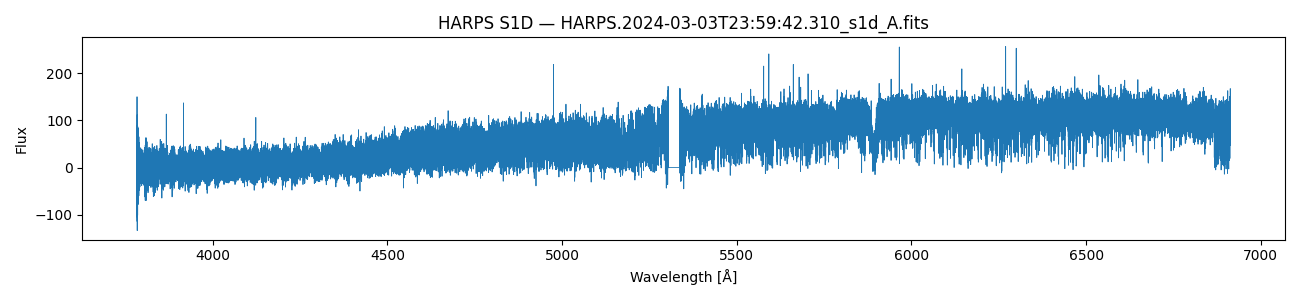

Wrote 61 entries → ./Automated_Program/HARPS_S1D.csv


,path,berv
0,/home/amasson/data/Kaperture_Science/Data/Post...,-20291.191239
1,/home/amasson/data/Kaperture_Science/Data/Post...,-20302.219652
2,/home/amasson/data/Kaperture_Science/Data/Post...,-20312.432795
3,/home/amasson/data/Kaperture_Science/Data/Post...,-20322.534739
4,/home/amasson/data/Kaperture_Science/Data/Post...,-20334.021672


In [8]:
# ── 1. Set path ──────────────────────────────────────────────────────────────
# S1D files live in the same directory as the e2ds files.
# Filename format: HARPS.<YYYY-MM-DDThh:mm:ss.sss>_s1d_A.fits
DATA_DIR_HARPS = '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/'   # ← edit this
CSV_HARPS      = './Automated_Program/HARPS_S1D.csv'

# ── 2. Find files & inspect ───────────────────────────────────────────────────
s1d_files = sorted(glob.glob(os.path.join(DATA_DIR_HARPS, '*s1d_A.fits')))
print(f"Found {len(s1d_files)} HARPS S1D files")
for f in s1d_files[:3]: print(' ', os.path.basename(f))

# ── 3. Peek at header of first file ───────────────────────────────────────────
with fits.open(s1d_files[0]) as h:
    print(h.info())
    print(repr(h[0].header[:20]))

# ── 4. Plot first spectrum ─────────────────────────────────────────────────────
# HARPS S1D: single 1D image in HDU0, wavelength built from WCS keywords (Å, air→vacuum by DRS)
with fits.open(s1d_files[0]) as h:
    wave = h[0].header['CRVAL1'] + np.arange(h[0].header['NAXIS1']) * h[0].header['CDELT1']
    flux = np.asarray(h[0].data, dtype=float)

plt.figure(figsize=(13, 3))
plt.plot(wave, flux, lw=0.6)
plt.xlabel('Wavelength [Å]');  plt.ylabel('Flux');  plt.title(f'HARPS S1D — {os.path.basename(s1d_files[0])}')
plt.tight_layout();  plt.show()

# ── 5. Build wrapper CSV ───────────────────────────────────────────────────────
# BERV header key: 'HIERARCH ESO DRS BERV' [km/s] → ×1e3 for m/s
df_harps = build_csv_from_s1d_dir(
    data_dir    = DATA_DIR_HARPS,
    pattern     = '*s1d_A.fits',
    berv_key    = 'HIERARCH ESO DRS BERV',
    csv_path    = CSV_HARPS,
    berv_factor = 1e3,
    sort_key    = 'HIERARCH ESO DRS BJD',
)
df_harps.head()


## ESPRESSO

In [ ]:
# ── 1. Set path ──────────────────────────────────────────────────────────────
# S1D files live in the same directory as the S2D files.
# Filename format: r.ESPRESSO.<YYYY-MM-DDThh:mm:ss.sss>_S1D_A.fits
DATA_DIR_ESPRESSO = '/path/to/ESPRESSO/reduced/night/'   # ← edit this
CSV_ESPRESSO      = './Automated_Program/ESPRESSO_S1D.csv'

# ── 2. Find files & inspect ───────────────────────────────────────────────────
s1d_files = sorted(glob.glob(os.path.join(DATA_DIR_ESPRESSO, '*S1D_A.fits')))
print(f"Found {len(s1d_files)} ESPRESSO S1D files")
for f in s1d_files[:3]: print(' ', os.path.basename(f))

# ── 3. Peek at header of first file ───────────────────────────────────────────
with fits.open(s1d_files[0]) as h:
    print(h.info())
    print(repr(h[0].header[:20]))

# ── 4. Plot first spectrum ─────────────────────────────────────────────────────
# ESPRESSO S1D: BinTable in HDU1 with columns 'WAVE' [Å] and 'FLUX'
with fits.open(s1d_files[0]) as h:
    wave = h[1].data['WAVE'][0] / 10.0    # Å → nm
    flux = h[1].data['FLUX'][0]

plt.figure(figsize=(13, 3))
plt.plot(wave, flux, lw=0.6)
plt.xlabel('Wavelength [nm]');  plt.ylabel('Flux');  plt.title(f'ESPRESSO S1D — {os.path.basename(s1d_files[0])}')
plt.tight_layout();  plt.show()

# ── 5. Build wrapper CSV ───────────────────────────────────────────────────────
# BERV header key: 'HIERARCH ESO QC BERV' [km/s] → ×1e3 for m/s
df_espresso = build_csv_from_s1d_dir(
    data_dir    = DATA_DIR_ESPRESSO,
    pattern     = '*S1D_A.fits',
    berv_key    = 'HIERARCH ESO QC BERV',
    csv_path    = CSV_ESPRESSO,
    berv_factor = 1e3,
    sort_key    = 'HIERARCH ESO QC BJD',
)
df_espresso.head()


## NIRPS

**Not required for most recent NIRPS DRS version!!**

Note: for recent NIRPS DRS output, there already exist telluric template computed following the method of Allart et al. XXX (to check...). Hence we don't necesseraly need Molecfit: the 'reduction.py' core module already allow for loading the existing NIRPS telluric template and correcting with them. 

In [ ]:
# ── 1. Set path ──────────────────────────────────────────────────────────────
# S1D files live in the same directory as the S2D_SKYSUB files.
# Filename format: r.NIRPS.<YYYY-MM-DDThh-mm-ss.sss>_S1D_FINAL_A.fits
# Note: colons in the timestamp are replaced by dashes in S1D filenames
#       (e.g. S2D_SKYSUB: ...T00:46:10... → S1D_FINAL: ...T00-46-10...)
DATA_DIR_NIRPS = '/path/to/NIRPS/reduced/night/'   # ← edit this
CSV_NIRPS      = './Automated_Program/NIRPS_S1D.csv'

# ── 2. Find files & inspect ───────────────────────────────────────────────────
s1d_files = sorted(glob.glob(os.path.join(DATA_DIR_NIRPS, '*S1D_FINAL*.fits')))
print(f"Found {len(s1d_files)} NIRPS S1D files")
for f in s1d_files[:3]: print(' ', os.path.basename(f))

# ── 3. Peek at header of first file ───────────────────────────────────────────
with fits.open(s1d_files[0]) as h:
    print(h.info())
    print(repr(h[0].header[:20]))

# ── 4. Plot first spectrum ─────────────────────────────────────────────────────
# NIRPS S1D: BinTable in HDU1 with columns 'Wave' [nm] and 'Flux'
with fits.open(s1d_files[0]) as h:
    wave = h[1].data['Wave'][0]
    flux = h[1].data['Flux'][0]

plt.figure(figsize=(13, 3))
plt.plot(wave, flux, lw=0.6)
plt.xlabel('Wavelength [nm]');  plt.ylabel('Flux');  plt.title(f'NIRPS S1D — {os.path.basename(s1d_files[0])}')
plt.tight_layout();  plt.show()

# ── 5. Build wrapper CSV ───────────────────────────────────────────────────────
# BERV header key: 'HIERARCH ESO QC BERV' [km/s] → ×1e3 for m/s
df_nirps = build_csv_from_s1d_dir(
    data_dir    = DATA_DIR_NIRPS,
    pattern     = '*S1D_FINAL*.fits',
    berv_key    = 'HIERARCH ESO QC BERV',
    csv_path    = CSV_NIRPS,
    berv_factor = 1e3,
    sort_key    = 'HIERARCH ESO QC BJD',
)
df_nirps.head()


## CARMENES VIS/NIR

In [ ]:
def load_e2ds_CARMENES(data_dir, channel='nir'):
    """
    Standalone loader for CARMENES sci_{channel}_A.fits files: load the e2ds files and convert them in flattened s1d files to be used by Molecfit.

    Parameters
    ----------
    data_dir : str
        Directory containing the CARACALAS-reduced files.
    channel  : str
        'vis' or 'nir'  (default 'nir').

    Returns a SimpleNamespace with:
        .path     : data_dir (with trailing /)
        .files    : list of filenames, sorted by BJD
        .data     : (n_obs, n_orders, n_pixels) float array
        .wave     : (n_obs, n_orders, n_pixels) float array [nm]
        .SNR      : (n_obs,) array  — order-30 SNR from HIERARCH CARACAL FOX SNR 30
        .BERV     : (n_obs,) array  — BERV in m/s
        .sky      : (n_obs, n_orders, n_pixels) float array from fiber-B sky
                    (or None if B files not found)
        .name     : string tag built from data_dir path parts
    """
    import types

    data_dir = data_dir.rstrip('/') + '/'
    ch = channel.lower()

    all_files = sorted(
        [f for f in os.listdir(data_dir) if 'sci' in f and f'{ch}_A.fits' in f]
    )
    if not all_files:
        raise FileNotFoundError(f"No sci*{ch}_A.fits files found in {data_dir}")

    bjd_list  = [fits.getheader(data_dir + f)['HIERARCH CARACAL BJD'] for f in all_files]
    all_files = [all_files[i] for i in np.argsort(bjd_list)]

    with fits.open(data_dir + all_files[0]) as h0:
        n_orders, n_pix = h0[1].data.shape

    n_obs = len(all_files)
    data  = np.zeros((n_obs, n_orders, n_pix), dtype=float)
    wave  = np.zeros_like(data)
    SNR   = np.zeros(n_obs)
    BERV  = np.zeros(n_obs)

    for k, fname in enumerate(all_files):
        with fits.open(data_dir + fname) as hdul:
            hdr         = hdul[0].header
            data[k]     = hdul[1].data
            wave[k]     = hdul[4].data / 10.0                    # Å → nm
            SNR[k]      = hdr['HIERARCH CARACAL FOX SNR 30']
            BERV[k]     = hdr['HIERARCH CARACAL BERV'] * 1e3     # m/s

    bad = np.all((data == 0) | ~np.isfinite(data), axis=0)
    data[:, bad] = np.nan

    # ── optional sky emission from fiber B ───────────────────────────────────────
    sky = None
    b_files = [f.replace('_A.fits', '_B.fits') for f in all_files]
    b_present = [os.path.exists(data_dir + bf) for bf in b_files]
    if all(b_present):
        sky = np.zeros_like(data)
        sky_wave = np.zeros_like(data)
        for k, bfname in enumerate(b_files):
            with fits.open(data_dir + bfname) as hb:
                sky_raw  = hb['SPEC'].data
                sw_raw   = hb['WAVE'].data / 10.0   # Å → nm
            for order in range(n_orders):
                sky[k, order] = interp1d(
                    sw_raw[order], sky_raw[order],
                    bounds_error=False, fill_value=np.nan
                )(wave[k, order])
        print("CARMENES: fiber-B sky emission loaded and interpolated onto science wavelength grid.")
    else:
        print("CARMENES: fiber-B sky files not found — 'sky' attribute set to None.")

    name = '_'.join(data_dir.rstrip('/').split('/')[-3:])

    dd = types.SimpleNamespace(
        path=data_dir, files=all_files, name=name, shape=data.shape,
        data=data, wave=wave, SNR=SNR, BERV=BERV, sky=sky,
    )
    print(f"CARMENES {ch.upper()}: loaded {n_obs} obs, shape {data.shape}  [{name}]")
    return dd


In [ ]:
# ── 1. Set paths ─────────────────────────────────────────────────────────────
DATA_DIR_CARMENES = '/path/to/CARMENES/reduced/night/'   # ← edit this
CSV_NIR = './Automated_Program/CARMENES_NIR_S1D.csv'
CSV_VIS = './Automated_Program/CARMENES_VIS_S1D.csv'

# ── 2. Find e2ds files & inspect ─────────────────────────────────────────────
nir_files = sorted(glob.glob(os.path.join(DATA_DIR_CARMENES, '*sci*nir_A.fits')))
vis_files = sorted(glob.glob(os.path.join(DATA_DIR_CARMENES, '*sci*vis_A.fits')))
print(f"Found {len(nir_files)} NIR  /  {len(vis_files)} VIS  science files")
for f in nir_files[:2]: print('  NIR:', os.path.basename(f))
for f in vis_files[:2]: print('  VIS:', os.path.basename(f))

# ── 3. Peek at header of first NIR file ──────────────────────────────────────
with fits.open(nir_files[0]) as h:
    print(repr(h[0].header[:20]))

# ── 4. Load e2ds cubes (needed to build S1D — CARMENES has no DRS S1D output) ─
dd_nir = load_e2ds_CARMENES(DATA_DIR_CARMENES, channel='nir')
dd_vis = load_e2ds_CARMENES(DATA_DIR_CARMENES, channel='vis')

# ── 5. Quick-look: first NIR spectrum (all orders overplotted) ────────────────
fig, ax = plt.subplots(figsize=(13, 3))
for order in range(dd_nir.data.shape[1]):
    ax.plot(dd_nir.wave[0, order], dd_nir.data[0, order], lw=0.4, color='k', alpha=0.3)
ax.set_xlabel('Wavelength [nm]');  ax.set_ylabel('Flux')
ax.set_title(f'CARMENES NIR e2ds — {dd_nir.files[0]}')
plt.tight_layout();  plt.show()


In [ ]:
# ── 6. Build S1D FITS + wrapper CSV ──────────────────────────────────────────
df_nir = prepare_s1d(dd_nir, output_dir='./s1d_carmenes_nir', csv_path=CSV_NIR, channel='nir')
df_vis = prepare_s1d(dd_vis, output_dir='./s1d_carmenes_vis', csv_path=CSV_VIS, channel='vis')
print(f"NIR: {len(df_nir)} files  |  VIS: {len(df_vis)} files")
df_nir.head()


In [ ]:
# ── 7. Quick-look: first generated NIR S1D ───────────────────────────────────
with fits.open(df_nir.path.iloc[0]) as h:
    wave = h[1].data['WAVE']
    flux = h[1].data['FLUX']

plt.figure(figsize=(13, 3))
plt.plot(wave, flux, lw=0.6)
plt.xlabel('Wavelength [nm]');  plt.ylabel('Flux')
plt.title(f'CARMENES NIR S1D (generated) — {os.path.basename(df_nir.path.iloc[0])}')
plt.tight_layout();  plt.show()


## Run Wrapper

In [ ]:
# Edit these two values in Molecfit_parallel_wrapper.py before running:
# - PATH_TO_LIST
# - CONFIGURED_CHANNEL_TYPE
#
# Example:
# PATH_TO_LIST = './Automated_Program/noKepler-91b_CARMENES_02-07-2019_CARMENES_NIR_S1D.csv'
# CONFIGURED_CHANNEL_TYPE = 'CARMENES_NIR'

!python Molecfit_parallel_wrapper.py


## Plot Molecfit Results

In [ ]:
# Point to one Molecfit output folder and spectrum index
run_dir = '/home/amasson/data/molecfit_wrapper/Output/output0_CARMENES_NIR_20260511_111821/'
spectrum_index = 0

plot_molecfit_result(run_dir, spectrum_index)


In [ ]:
# Optional: discover latest output folder for a channel tag
tag = 'CARMENES_NIR'
cands = sorted(glob.glob(f'/home/amasson/data/molecfit_wrapper/Output/output*_{tag}_*'))
print('Found:', len(cands))
for c in cands[-5:]:
    print(c)
